# 재무지표 기반 투자 전략 백테스팅 예제

이 노트북의 목표는 **재무제표와 재무비율을 투자 전략으로 연결하고, 과거 데이터로 검증하는 흐름**을 보여주는 것입니다.

다루는 전략:

1. 저PER 전략
2. 저PBR 전략
3. 고배당 전략
4. 저PER + 저PBR 결합 전략
5. 시가총액 상위 종목 필터를 적용한 저PER 전략

> 수업용 핵심 메시지:  
> 재무비율은 단순히 외우는 숫자가 아니라, 투자 규칙으로 바꾸어 검증할 수 있는 데이터입니다.


## 0. 사전 준비

한국 주식 데이터는 `pykrx`를 사용합니다.

- 가격 데이터
- 시가총액
- PER, PBR, EPS, BPS, 배당수익률 등 기본 재무지표

In [1]:
# 처음 한 번만 실행하면 됩니다.
# !pip install pykrx pandas numpy matplotlib

In [2]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv

# .env 파일에서 KRX_ID, KRX_PW를 읽어 환경변수에 등록합니다.
# 이 셀이 pykrx 호출보다 먼저 실행되어야 합니다.
load_dotenv()

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 1. 리밸런싱 날짜 설정

이 예제에서는 매년 5월 초에 포트폴리오를 다시 구성한다고 가정합니다.

왜 5월인가?

- 한국 기업의 전년도 사업보고서는 보통 3월 말까지 제출됩니다.
- 5월 초를 기준으로 잡으면 전년도 재무정보가 어느 정도 시장 데이터에 반영되었다고 단순 가정하기 쉽습니다.
- 물론 실제 백테스팅에서는 보고서 제출일 기준으로 look-ahead bias를 더 엄격하게 관리해야 합니다.


In [3]:
# 매년 5월 첫 거래일 근처를 단순 지정한 예시입니다.
# 실제 수업에서는 이 리스트를 고정해두면 재현성이 좋아집니다.

REBALANCE_DATES = [
    "20140502", "20150504", "20160502", "20170502",
    "20180502", "20190502", "20200504", "20210503",
    "20220502", "20230502", "20240502", "20250502"
]

START_DATE = "20140101"
END_DATE = "20260501"

MARKET = "KOSPI"  # "KOSPI", "KOSDAQ", "ALL" 중 선택 가능

## 2. pykrx로 데이터 가져오기

아래 셀은 시간이 걸릴 수 있습니다.

수집하는 데이터:

- 연도별 리밸런싱 시점의 재무지표: PER, PBR, EPS, BPS, DIV, DPS
- 연도별 리밸런싱 시점의 시가총액
- 월별 종가 데이터

In [4]:
def fetch_fundamentals_from_pykrx(rebalance_dates, market="KOSPI", sleep_sec=1.0):
    """리밸런싱 날짜별 전체 종목 재무지표와 시가총액을 수집합니다."""
    from pykrx import stock

    all_rows = []

    for date in rebalance_dates:
        print(f"Fetching fundamentals: {date}")

        fundamental = stock.get_market_fundamental_by_ticker(date, market=market)
        ohlcv = stock.get_market_ohlcv_by_ticker(date, market=market)
        market_cap = stock.get_market_cap_by_ticker(date, market=market)

        df = fundamental.join(ohlcv, how="left").join(market_cap, how="left", rsuffix="_mcap")
        df["date"] = pd.to_datetime(date)
        df["ticker"] = df.index
        df["name"] = [stock.get_market_ticker_name(ticker) for ticker in df.index]

        all_rows.append(df.reset_index(drop=True))
        time.sleep(sleep_sec)

    result = pd.concat(all_rows, ignore_index=True)
    return result


def fetch_monthly_prices_from_pykrx(start_date, end_date, base_date, market="KOSPI", sleep_sec=0.2, limit_tickers=None):
    """종목별 월별 OHLCV 데이터를 수집합니다."""
    from pykrx import stock

    tickers = stock.get_market_ticker_list(base_date, market=market)

    if limit_tickers is not None:
        tickers = tickers[:limit_tickers]

    price_rows = []

    for i, ticker in enumerate(tickers, start=1):
        name = stock.get_market_ticker_name(ticker)
        print(f"[{i}/{len(tickers)}] Fetching monthly prices: {ticker} {name}")

        try:
            df = stock.get_market_ohlcv(start_date, end_date, ticker, freq="m")
            if len(df) == 0:
                continue

            df = df.reset_index()
            df["ticker"] = ticker
            df["name"] = name
            price_rows.append(df)
        except Exception as e:
            print(f"  - skipped {ticker}: {e}")

        time.sleep(sleep_sec)

    result = pd.concat(price_rows, ignore_index=True)
    return result

In [5]:
import os

# 전체 KOSPI 월별 가격 수집은 시간이 걸릴 수 있습니다.
# 이전에 저장해둔 pickle 파일이 있으면 그걸 불러오고, 없으면 새로 받습니다.
# 새로 받은 데이터는 아래 2.5 셀에서 저장할 수 있습니다.

FUNDAMENTALS_PATH = "fundamentals.pkl"
PRICES_PATH = "prices.pkl"

if os.path.exists(FUNDAMENTALS_PATH) and os.path.exists(PRICES_PATH):
    print("저장된 pickle 파일을 불러옵니다.")
    fundamentals = pd.read_pickle(FUNDAMENTALS_PATH)
    prices = pd.read_pickle(PRICES_PATH)
else:
    print("저장된 파일이 없어 pykrx에서 새로 받습니다. (시간이 걸릴 수 있습니다)")
    fundamentals = fetch_fundamentals_from_pykrx(REBALANCE_DATES, market=MARKET)
    prices = fetch_monthly_prices_from_pykrx(
        START_DATE,
        END_DATE,
        base_date=REBALANCE_DATES[-1],
        market=MARKET
    )

print(f"Fundamentals shape: {fundamentals.shape}")
print(f"Prices shape: {prices.shape}")

저장된 pickle 파일을 불러옵니다.
Fundamentals shape: (10648, 22)
Prices shape: (128733, 8)


## 2.5 데이터 저장 (선택)

pykrx로 데이터를 받는 데 시간이 오래 걸리므로, 한 번 받은 데이터는 파일로 저장해두면 좋습니다.
다음에 노트북을 다시 열 때는 위 2번 셀이 이 파일을 자동으로 불러옵니다.

In [6]:
# 데이터를 받은 뒤 이 셀을 실행하면 같은 폴더에 pickle 파일로 저장됩니다.
# 다음에 노트북을 열면 위 2번 셀이 자동으로 이 파일을 불러옵니다.
# 데이터를 다시 받고 싶다면 이 두 파일을 삭제하세요.

fundamentals.to_pickle("fundamentals.pkl")
prices.to_pickle("prices.pkl")

print("fundamentals.pkl, prices.pkl 저장 완료")

fundamentals.pkl, prices.pkl 저장 완료


## 3. 데이터 정리

백테스팅에서 특히 조심할 점:

- PER이 0이거나 음수인 기업은 제외
- PBR이 0이거나 음수인 기업은 제외
- 시가총액이 너무 작은 기업은 유동성 문제가 있을 수 있으므로 제외 가능
- 상장폐지 종목을 빼면 생존편향이 생길 수 있음
- 재무지표가 실제로 언제 투자자에게 공개되었는지 확인하지 않으면 look-ahead bias가 생길 수 있음

In [7]:
def clean_fundamentals(df):
    result = df.copy()

    # 컬럼명 통일
    result = result.rename(columns={
        "시가총액": "market_cap",
        "종가": "close"
    })

    result["date"] = pd.to_datetime(result["date"])
    result["ticker"] = result["ticker"].astype(str).str.zfill(6)

    for col in ["PER", "PBR", "EPS", "BPS", "DIV", "market_cap", "close"]:
        if col in result.columns:
            result[col] = pd.to_numeric(result[col], errors="coerce")

    # 분석에 필요한 핵심 값이 없는 행 제거
    result = result.dropna(subset=["date", "ticker", "PER", "PBR", "DIV", "market_cap"])

    return result


def clean_prices(df):
    result = df.copy()
    result["날짜"] = pd.to_datetime(result["날짜"])
    result["ticker"] = result["ticker"].astype(str).str.zfill(6)
    result["종가"] = pd.to_numeric(result["종가"], errors="coerce")
    result = result.dropna(subset=["날짜", "ticker", "종가"])
    return result


fundamentals_clean = clean_fundamentals(fundamentals)
prices_clean = clean_prices(prices)

display(fundamentals_clean.head())
display(prices_clean.head())

,BPS,PER,PBR,EPS,DIV,DPS,시가,고가,저가,close,거래량,거래대금,등락률,market_cap,종가_mcap,시가총액_mcap,거래량_mcap,거래대금_mcap,상장주식수,date,ticker,name
0,8589,20.66,1.96,813,0.00,0,16550,16850,16350,16800,118133,1957674900,1.51,372057840000,16800,372057840000,118133,1957674900,22146300,2014-05-02,068400,SK렌터카
1,36611,7.66,1.53,7296,0.36,200,53200,56400,53100,55900,49618,2744092000,4.88,651098659900,55900,651098659900,49618,2744092000,11647561,2014-05-02,006840,AK홀딩스
2,18104,9.99,0.87,1576,1.78,280,15700,15800,15500,15750,424190,6656203500,-0.32,3045733409250,15750,3045733409250,424190,6656203500,193379899,2014-05-02,138930,BNK금융지주
3,414146,9.50,0.56,24570,0.32,750,232000,234000,225000,233500,238,54659500,-0.21,145847602500,233500,145847602500,238,54659500,624615,2014-05-02,001460,BYC
4,0,0.00,0.00,0,0.85,800,91800,94900,91700,94300,660,61621500,2.84,20310805500,94300,20310805500,660,61621500,215385,2014-05-02,001465,BYC우


,날짜,시가,고가,저가,종가,거래량,ticker,name
0,2015-08-31,6180,8060,5600,6700,4227555,095570,AJ네트웍스
1,2015-09-30,6840,8880,6400,8770,1640189,095570,AJ네트웍스
2,2015-10-31,8790,10380,8109,9480,820945,095570,AJ네트웍스
3,2015-11-30,9480,9860,8260,8420,593236,095570,AJ네트웍스
4,2015-12-31,8580,9960,8450,9420,384406,095570,AJ네트웍스


## 4. 다음 리밸런싱 시점까지의 수익률 계산

매년 5월에 종목을 고르고, 다음 해 5월까지 보유한다고 가정합니다.

수익률 계산 방식:

\[
수익률 = \frac{다음\ 리밸런싱\ 시점의\ 가격}{현재\ 리밸런싱\ 시점의\ 가격} - 1
\]

단순화를 위해 배당은 제외합니다.  
실제 백테스팅에서는 배당 포함 총수익률을 쓰는 것이 더 좋습니다.

In [8]:
def get_nearest_monthly_price(prices_df, ticker, target_date):
    """target_date 이후 가장 가까운 월별 가격을 찾습니다."""
    sub = prices_df[(prices_df["ticker"] == ticker) & (prices_df["날짜"] >= target_date)].sort_values("날짜")
    if len(sub) == 0:
        return np.nan
    return sub.iloc[0]["종가"]


def add_forward_returns(fundamentals_df, prices_df, rebalance_dates):
    result_rows = []
    date_list = [pd.to_datetime(d) for d in rebalance_dates]

    for current_date, next_date in zip(date_list[:-1], date_list[1:]):
        universe = fundamentals_df[fundamentals_df["date"] == current_date].copy()

        if len(universe) == 0:
            continue

        current_prices = []
        next_prices = []

        for ticker in universe["ticker"]:
            current_price = get_nearest_monthly_price(prices_df, ticker, current_date)
            next_price = get_nearest_monthly_price(prices_df, ticker, next_date)
            current_prices.append(current_price)
            next_prices.append(next_price)

        universe["current_price"] = current_prices
        universe["next_price"] = next_prices
        universe["next_date"] = next_date
        universe["next_return"] = universe["next_price"] / universe["current_price"] - 1

        result_rows.append(universe)

    result = pd.concat(result_rows, ignore_index=True)
    result = result.dropna(subset=["next_return"])
    return result


backtest_data = add_forward_returns(fundamentals_clean, prices_clean, REBALANCE_DATES)

display(backtest_data.head())
print(backtest_data.shape)

,BPS,PER,PBR,EPS,DIV,DPS,시가,고가,저가,close,거래량,거래대금,등락률,market_cap,종가_mcap,시가총액_mcap,거래량_mcap,거래대금_mcap,상장주식수,date,ticker,name,current_price,next_price,next_date,next_return
1,36611,7.66,1.53,7296,0.36,200,53200,56400,53100,55900,49618,2744092000,4.88,651098659900,55900,651098659900,49618,2744092000,11647561,2014-05-02,006840,AK홀딩스,69106.0,92100.0,2015-05-04,0.332735
2,18104,9.99,0.87,1576,1.78,280,15700,15800,15500,15750,424190,6656203500,-0.32,3045733409250,15750,3045733409250,424190,6656203500,193379899,2014-05-02,138930,BNK금융지주,14945.0,15089.0,2015-05-04,0.009635
3,414146,9.50,0.56,24570,0.32,750,232000,234000,225000,233500,238,54659500,-0.21,145847602500,233500,145847602500,238,54659500,624615,2014-05-02,001460,BYC,22900.0,36750.0,2015-05-04,0.604803
4,0,0.00,0.00,0,0.85,800,91800,94900,91700,94300,660,61621500,2.84,20310805500,94300,20310805500,660,61621500,215385,2014-05-02,001465,BYC우,95900.0,182500.0,2015-05-04,0.903024
5,103118,24.24,1.24,5280,0.74,950,126000,130500,125500,128000,83974,10816981000,2.40,3718252544000,128000,3718252544000,83974,10816981000,29048848,2014-05-02,001040,CJ,134373.0,226312.0,2015-05-04,0.684207


(9205, 26)


## 5. 투자 전략 정의

이 예제에서는 동일가중 포트폴리오를 사용합니다.

즉, 선택된 종목을 모두 같은 비중으로 산다고 가정합니다.

전략:

1. 시장 전체: 모든 종목 동일가중
2. 저PER: PER이 낮은 상위 20%
3. 저PBR: PBR이 낮은 상위 20%
4. 고배당: 배당수익률이 높은 상위 20%
5. 저PER + 저PBR: PER 하위 30% 안에서 PBR 하위 30%
6. 대형주 저PER: 시가총액 상위 200개 중 PER 하위 20%

In [9]:
def select_market(df):
    return df.copy()


def select_low_per(df, quantile=0.2):
    valid = df[df["PER"] > 0].copy()
    cutoff = valid["PER"].quantile(quantile)
    return valid[valid["PER"] <= cutoff]


def select_low_pbr(df, quantile=0.2):
    valid = df[df["PBR"] > 0].copy()
    cutoff = valid["PBR"].quantile(quantile)
    return valid[valid["PBR"] <= cutoff]


def select_high_dividend(df, quantile=0.8):
    valid = df[df["DIV"] > 0].copy()
    cutoff = valid["DIV"].quantile(quantile)
    return valid[valid["DIV"] >= cutoff]


def select_low_per_low_pbr(df, quantile=0.3):
    valid = df[(df["PER"] > 0) & (df["PBR"] > 0)].copy()
    per_cutoff = valid["PER"].quantile(quantile)
    pbr_cutoff = valid["PBR"].quantile(quantile)
    return valid[(valid["PER"] <= per_cutoff) & (valid["PBR"] <= pbr_cutoff)]


def select_large_cap_low_per(df, top_n=200, quantile=0.2):
    valid = df[(df["PER"] > 0) & (df["market_cap"] > 0)].copy()
    large = valid.sort_values("market_cap", ascending=False).head(top_n)
    cutoff = large["PER"].quantile(quantile)
    return large[large["PER"] <= cutoff]


STRATEGIES = {
    "Market Equal Weight": select_market,
    "Low PER": select_low_per,
    "Low PBR": select_low_pbr,
    "High Dividend": select_high_dividend,
    "Low PER + Low PBR": select_low_per_low_pbr,
    "Large-Cap Low PER": select_large_cap_low_per,
}

## 6. 백테스팅 실행

각 리밸런싱 날짜마다 전략별로 종목을 고른 뒤, 다음 리밸런싱 날짜까지의 평균 수익률을 계산합니다.

In [10]:
def run_backtest(data, strategies):
    rows = []

    for date, group in data.groupby("date"):
        for strategy_name, selector in strategies.items():
            selected = selector(group)

            if len(selected) == 0:
                portfolio_return = np.nan
            else:
                portfolio_return = selected["next_return"].mean()

            rows.append({
                "date": date,
                "strategy": strategy_name,
                "n_stocks": len(selected),
                "return": portfolio_return,
                "avg_PER": selected["PER"].replace(0, np.nan).mean() if len(selected) else np.nan,
                "avg_PBR": selected["PBR"].replace(0, np.nan).mean() if len(selected) else np.nan,
                "avg_DIV": selected["DIV"].replace(0, np.nan).mean() if len(selected) else np.nan,
            })

    result = pd.DataFrame(rows)
    result = result.sort_values(["strategy", "date"])
    result["cumulative_return"] = result.groupby("strategy")["return"].transform(lambda x: (1 + x.fillna(0)).cumprod() - 1)

    return result


backtest_result = run_backtest(backtest_data, STRATEGIES)

display(backtest_result.head(12))

,date,strategy,n_stocks,return,avg_PER,avg_PBR,avg_DIV,cumulative_return
3,2014-05-02,High Dividend,106,0.291144,17.476857,0.899615,4.072642,0.291144
9,2015-05-04,High Dividend,110,-0.019239,16.610417,1.016914,3.777818,0.266304
15,2016-05-02,High Dividend,111,0.111338,15.799036,0.995517,4.111802,0.407291
21,2017-05-02,High Dividend,117,0.020215,15.611358,0.975349,4.054359,0.435740
27,2018-05-02,High Dividend,123,-0.071201,19.217586,1.006067,4.166829,0.333513
33,2019-05-02,High Dividend,125,-0.141567,15.341446,0.874396,4.582480,0.144732
39,2020-05-04,High Dividend,123,0.688857,9.401099,0.541170,6.618862,0.933288
45,2021-05-03,High Dividend,123,0.010283,11.136180,0.850612,4.577480,0.953167
51,2022-05-02,High Dividend,130,-0.113458,7.727041,0.621584,5.678769,0.731565
57,2023-05-02,High Dividend,131,0.070004,11.245714,0.515600,6.320916,0.852782


## 7. 성과 요약

확인할 지표:

- 연평균 수익률
- 누적 수익률
- 변동성
- 최대낙폭
- 승률
- 평균 편입 종목 수

In [11]:
def max_drawdown(returns):
    wealth = (1 + returns.fillna(0)).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min()


def summarize_performance(result):
    rows = []

    for strategy, group in result.groupby("strategy"):
        returns = group["return"].dropna()
        if len(returns) == 0:
            continue

        total_return = (1 + returns).prod() - 1
        annual_return = (1 + total_return) ** (1 / len(returns)) - 1
        volatility = returns.std()
        mdd = max_drawdown(returns)
        win_rate = (returns > 0).mean()
        avg_n_stocks = group["n_stocks"].mean()

        rows.append({
            "strategy": strategy,
            "periods": len(returns),
            "annual_return": annual_return,
            "total_return": total_return,
            "volatility": volatility,
            "max_drawdown": mdd,
            "win_rate": win_rate,
            "avg_n_stocks": avg_n_stocks,
        })

    summary = pd.DataFrame(rows)
    summary = summary.sort_values("annual_return", ascending=False)
    return summary


summary = summarize_performance(backtest_result)

summary_display = summary.copy()

for col in ["annual_return", "total_return", "volatility", "max_drawdown", "win_rate"]:
    if col in summary_display.columns:
        summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")

display(summary_display)

,strategy,periods,annual_return,total_return,volatility,max_drawdown,win_rate,avg_n_stocks
2,Low PBR,11,9.80%,179.77%,31.47%,-27.17%,63.64%,150.181818
0,High Dividend,11,7.16%,114.07%,23.42%,-20.27%,63.64%,120.909091
5,Market Equal Weight,11,6.36%,97.03%,25.51%,-22.08%,63.64%,836.818182
4,Low PER + Low PBR,11,5.87%,87.25%,26.03%,-30.13%,63.64%,86.909091
3,Low PER,11,3.81%,50.80%,25.79%,-29.16%,36.36%,111.909091
1,Large-Cap Low PER,11,1.94%,23.56%,25.31%,-35.57%,45.45%,40.000000


## 8. 누적수익률 시각화

전략별 누적수익률을 비교합니다.

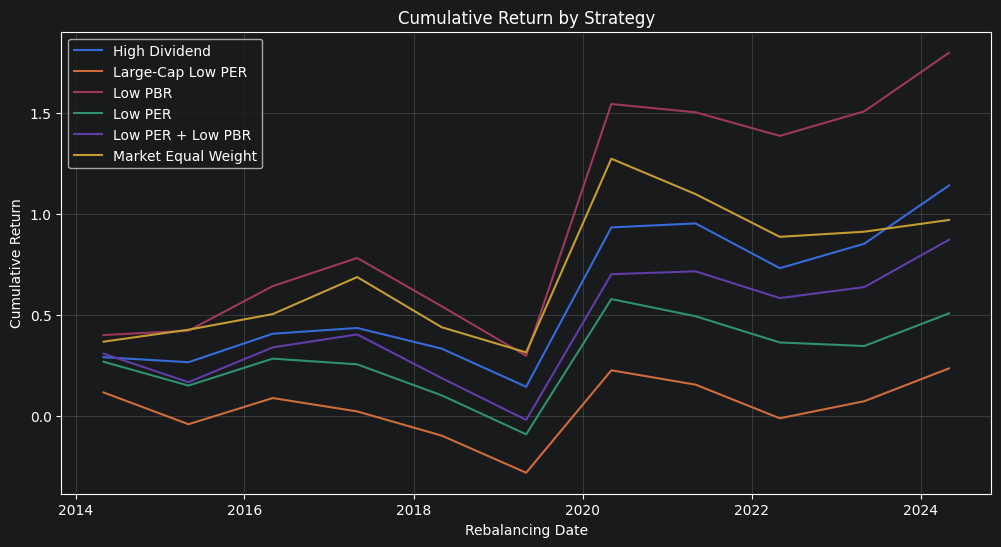

In [12]:
plt.figure(figsize=(12, 6))

for strategy, group in backtest_result.groupby("strategy"):
    group = group.sort_values("date")
    plt.plot(group["date"], group["cumulative_return"], label=strategy)

plt.title("Cumulative Return by Strategy")
plt.xlabel("Rebalancing Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. 연도별 수익률 비교

각 전략이 매년 항상 좋은 것은 아닙니다.  
백테스팅에서 중요한 것은 단순히 최종 수익률만 보는 것이 아니라, **어떤 시기에 강하고 약했는지**를 함께 보는 것입니다.

strategy,High Dividend,Large-Cap Low PER,Low PBR,Low PER,Low PER + Low PBR,Market Equal Weight
date,,,,,,
2014-05-02,29.11%,11.68%,40.09%,26.86%,30.87%,36.80%
2015-05-04,-1.92%,-14.08%,1.53%,-9.29%,-10.79%,4.33%
2016-05-02,11.13%,13.51%,15.51%,11.58%,14.76%,5.41%
2017-05-02,2.02%,-6.08%,8.48%,-2.18%,4.78%,12.18%
2018-05-02,-7.12%,-11.70%,-13.41%,-12.23%,-15.40%,-14.70%
2019-05-02,-14.16%,-20.33%,-15.89%,-17.48%,-17.41%,-8.65%
2020-05-04,68.89%,70.42%,95.99%,73.57%,73.50%,72.88%
2021-05-03,1.03%,-5.78%,-1.61%,-5.39%,0.83%,-7.71%
2022-05-02,-11.35%,-14.41%,-4.66%,-8.68%,-7.71%,-10.07%


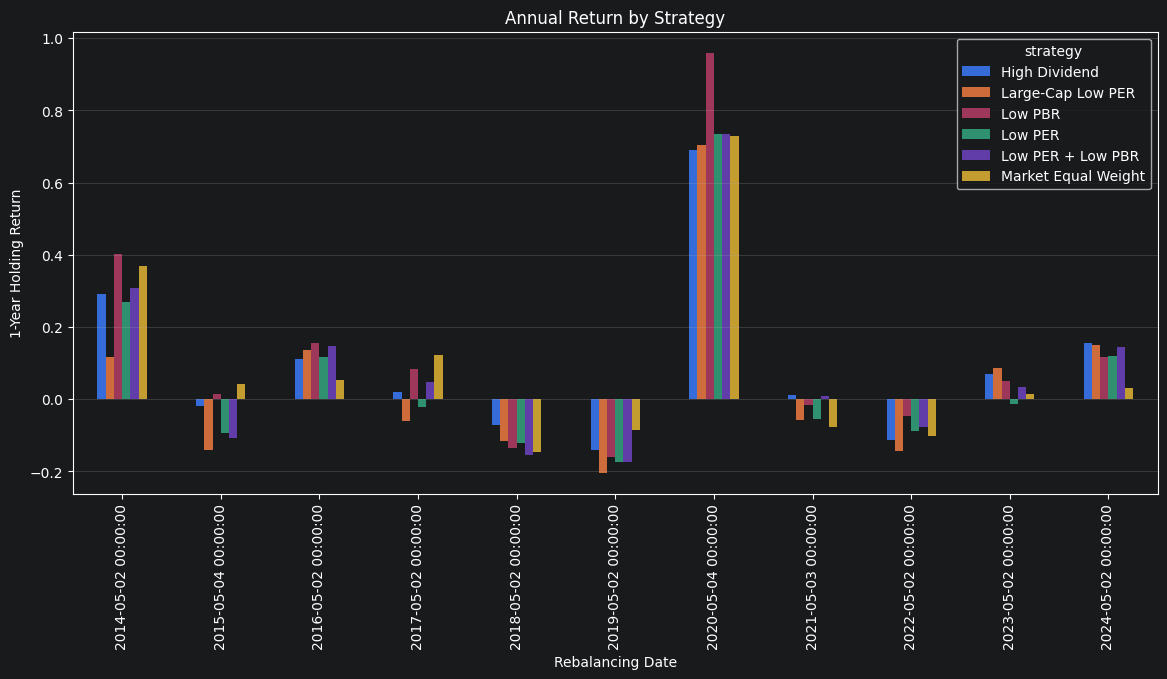

In [13]:
pivot_returns = backtest_result.pivot(
    index="date",
    columns="strategy",
    values="return"
)

# Display without using .style, so it does not require jinja2
pivot_returns_display = pivot_returns.copy()

for col in pivot_returns_display.columns:
    pivot_returns_display[col] = pivot_returns_display[col].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else ""
    )

display(pivot_returns_display)

# Plot annual returns by strategy
pivot_returns.plot(kind="bar", figsize=(14, 6))

plt.title("Annual Return by Strategy")
plt.xlabel("Rebalancing Date")
plt.ylabel("1-Year Holding Return")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 10. 특정 전략의 편입 종목 확인

백테스팅 결과만 보면 숫자놀음이 되기 쉽습니다.  
실제로 어떤 종목이 선택되었는지 확인해야 전략의 의미를 이해할 수 있습니다.

In [14]:
def show_selected_stocks(data, date, strategy_name, top_n=20):
    date = pd.to_datetime(date)

    group = data[data["date"] == date]

    if strategy_name not in STRATEGIES:
        raise ValueError(f"Unknown strategy: {strategy_name}")

    selected = STRATEGIES[strategy_name](group)

    cols = [
        "date",
        "ticker",
        "name",
        "PER",
        "PBR",
        "DIV",
        "market_cap",
        "next_return"
    ]

    selected = selected[cols].sort_values("next_return", ascending=False)

    return selected.head(top_n)


show_selected_stocks(
    backtest_data,
    "2024-05-02",
    "Low PER",
    top_n=20
)

,date,ticker,name,PER,PBR,DIV,market_cap,next_return
8835,2024-05-02,012630,HDC,3.96,0.17,3.53,507804628500,1.465409
8957,2024-05-02,036530,SNT홀딩스,3.75,0.31,3.53,369283017900,1.363636
9029,2024-05-02,092790,넥스틸,1.39,0.44,9.20,197875220000,1.214386
9671,2024-05-02,017800,현대엘리베이터,4.70,1.13,9.98,1567604638500,0.890411
9371,2024-05-02,111770,영원무역,3.26,0.52,3.39,1697129224400,0.787923
9477,2024-05-02,071320,지역난방공사,2.40,0.22,0.00,459676136800,0.761161
9675,2024-05-02,005440,현대지에프홀딩스,0.40,0.28,4.12,757694902860,0.632385
9309,2024-05-02,005390,신성통상,3.16,0.62,2.73,263273770480,0.599462
9305,2024-05-02,016590,신대양제지,4.43,0.34,2.49,242592876400,0.547812
9198,2024-05-02,001270,부국증권,3.71,0.28,6.30,246803286800,0.520576


## 11. 수업에서 강조할 한계

이 예제는 교육용입니다. 실제 투자 전략 검증에는 더 많은 주의가 필요합니다.

대표적인 한계:

1. **생존편향**  
   현재 남아 있는 종목만 쓰면 과거에 상장폐지된 기업이 빠질 수 있습니다.

2. **look-ahead bias**  
   특정 시점에 실제로 알 수 없었던 재무정보를 사용하면 결과가 과대평가됩니다.

3. **거래비용과 세금 미반영**  
   매매수수료, 세금, 슬리피지 등을 반영해야 실제 수익률에 가까워집니다.

4. **배당 미반영**  
   장기 백테스팅에서는 가격수익률보다 배당 포함 총수익률이 더 적절합니다.

5. **소형주 유동성 문제**  
   시가총액이 작은 종목은 실제로 원하는 가격에 매수·매도하기 어려울 수 있습니다.

6. **단일 지표의 위험**  
   PER, PBR 하나만으로 기업을 평가하면 회계 왜곡, 경기순환, 일회성 이익을 놓칠 수 있습니다.

## 12. 마무리 질문

수업 마지막에 다음 질문을 던지면 좋습니다.

- 저PER 전략이 항상 좋은가?
- 저PBR 기업은 정말 싼 기업인가, 아니면 문제가 있는 기업인가?
- 고배당 기업은 안정적인가, 아니면 성장 기회가 부족한 기업인가?
- 좋은 전략은 높은 수익률만으로 판단할 수 있는가?
- 재무제표 지식은 백테스팅 결과를 해석하는 데 왜 필요한가?

핵심 결론:

> 백테스팅은 정답을 알려주는 도구가 아니라, 투자 아이디어를 검증하고 질문을 더 정교하게 만드는 도구입니다.